## Lending Club Loan Default Prediction
## Clasificación supervisada: scikit-learn vs PySpark + LIME
---

Juan Sanchez, David Florez


> **EDA**: PySpark
> **Modelado**: scikit-learn Y PySpark

## 1. Configuración de SparkSession

In [1]:
import os
import time
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

from pyspark.sql import SparkSession
from pyspark import StorageLevel
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType, StringType

spark = SparkSession.builder \
    .appName('LendingClub_Optimized') \
    .config('spark.sql.shuffle.partitions', '200') \
    .config('spark.default.parallelism', '200') \
    .config('spark.executor.memory', '12g') \
    .config('spark.driver.memory', '12g') \
    .config('spark.driver.maxResultSize', '4g') \
    .config('spark.memory.fraction', 0.8) \
    .config('spark.memory.storageFraction', 0.3) \
    .config('spark.sql.execution.arrow.pyspark.enabled', 'false') \
    .config('spark.worker.cleanup.enabled', 'true') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print(f'SparkSession lista. Versión: {spark.version}')

SparkSession lista. Versión: 4.1.1


## 2. Carga del dataset completo

In [ ]:
DATA_PATH = r"C:\Users\juanc\Downloads\accepted_2007_to_2018Q4\accepted_2007_to_2018Q4.csv"

print('Cargando dataset con PySpark...')
t0 = time.time()
sdf = spark.read \
    .option('multiLine', 'false') \
    .option('quote', '"') \
    .option('escape', '"') \
    .option('mode', 'DROPMALFORMED') \
    .csv(DATA_PATH, header=True, inferSchema=True)
t_load = time.time() - t0

print(f'Tiempo de carga: {t_load:.2f}s')
print(f'Columnas totales: {len(sdf.columns)}')
sdf.show(5)
sdf.printSchema()

Cargando dataset con PySpark...
Tiempo de carga: 8.83s
Columnas totales: 151
+--------+---------+---------+-----------+---------------+----------+--------+-----------+-----+---------+--------------------+----------+--------------+----------+-------------------+--------+-----------+----------+--------------------+----+------------------+------------------+--------+----------+-----+-----------+----------------+--------------+---------------+--------------+----------------------+----------------------+--------+-------+---------+----------+---------+-------------------+---------+-------------+------------------+---------------+---------------+-------------+------------------+----------+-----------------------+------------+---------------+------------+------------------+--------------------+-------------------+--------------------------+---------------------------+-----------+----------------+----------------+---------+-------------------------+--------------+------------+-----------+------

In [ ]:
# Filtrar registros válidos y crear variable objetivo
sdf = sdf.filter(F.col('loan_status').isin(['Fully Paid', 'Charged Off']))
sdf = sdf.withColumn('default',
    F.when(F.col('loan_status') == 'Charged Off', 1).otherwise(0).cast(IntegerType())
)
# Limpiar term: ' 36 months' -> 36.0
if 'term' in sdf.columns:
    sdf = sdf.withColumn('term_months',
        F.regexp_extract(F.col('term'), r'(\d+)', 1).cast(DoubleType())
    )

# Cachear el DataFrame base
sdf = sdf.persist(StorageLevel.MEMORY_AND_DISK)
n_valid = sdf.count()
print(f'Registros válidos: {n_valid:,}')

Registros válidos: 1,345,310


## 3. Análisis Exploratorio de Datos (EDA) — PySpark

### 3.1 Variable objetivo

Distribución de la variable objetivo:
  Fully Paid (0): 1,076,751 (80.04%)
  Charged Off (1): 268,559 (19.96%)


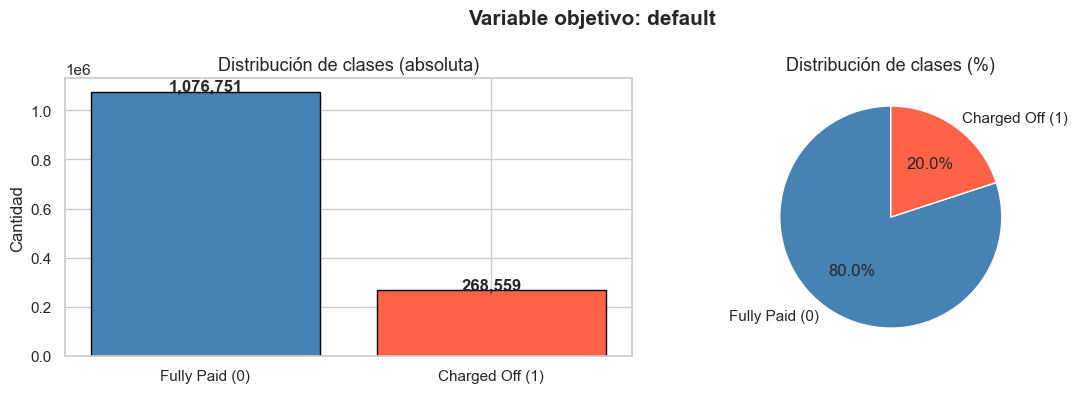

⚠️  Desbalance de clases. Se usarán métricas F1 y ROC AUC.


In [ ]:
target_dist = sdf.groupBy('default').count().orderBy('default').collect()
labels = ['Fully Paid (0)', 'Charged Off (1)']
counts = [r['count'] for r in target_dist]
total  = sum(counts)

print('Distribución de la variable objetivo:')
for label, count in zip(labels, counts):
    print(f'  {label}: {count:,} ({count/total*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, counts, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribución de clases (absoluta)', fontsize=13)
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(counts):
    axes[0].text(i, v + total*0.003, f'{v:,}', ha='center', fontweight='bold')
axes[1].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Distribución de clases (%)', fontsize=13)
plt.suptitle('Variable objetivo: default', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('⚠️  Desbalance de clases. Se usarán métricas F1 y ROC AUC.')

### 3.2 Estadísticas descriptivas — Variables numéricas

In [ ]:
NUM_COLS = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_high',
            'installment', 'open_acc', 'revol_util', 'total_acc', 'mort_acc']
NUM_COLS = [c for c in NUM_COLS if c in sdf.columns]

print('=== Estadísticas descriptivas ===')
sdf.select(NUM_COLS).describe().show(truncate=False)

print('\n=== Percentiles + IQR + Missing ===')
print(f'{"Variable":<25} {"Q1":>10} {"Mediana":>10} {"Q3":>10} {"IQR":>10} {"Missing%":>10}')
print('-' * 75)
for col in NUM_COLS:
    try:
        q1, median, q3 = sdf.approxQuantile(col, [0.25, 0.50, 0.75], 0.01)
        iqr     = q3 - q1
        missing = sdf.filter(F.col(col).isNull()).count()
        missing_pct = round(missing / n_valid * 100, 2)
        print(f'{col:<25} {q1:>10.4f} {median:>10.4f} {q3:>10.4f} {iqr:>10.4f} {missing_pct:>9.2f}%')
    except Exception as e:
        print(f'{col:<25} ERROR: {str(e)[:40]}')

=== Estadísticas descriptivas ===
+-------+------------------+-----------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|summary|loan_amnt         |int_rate         |annual_inc       |dti               |fico_range_high   |installment       |open_acc          |revol_util        |total_acc         |mort_acc          |
+-------+------------------+-----------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|count  |1345310           |1345310          |1345310          |1344936           |1345310           |1345310           |1345310           |1344453           |1345310           |1298029           |
|mean   |14419.972013885275|13.23961898744545|76247.63641372618|18.282666915005624|700.1851773940579 |438.07553293293125|11.593520452535103|51.81002191225726 |24.980838617121

### 3.3 Histogramas — Variables numéricas

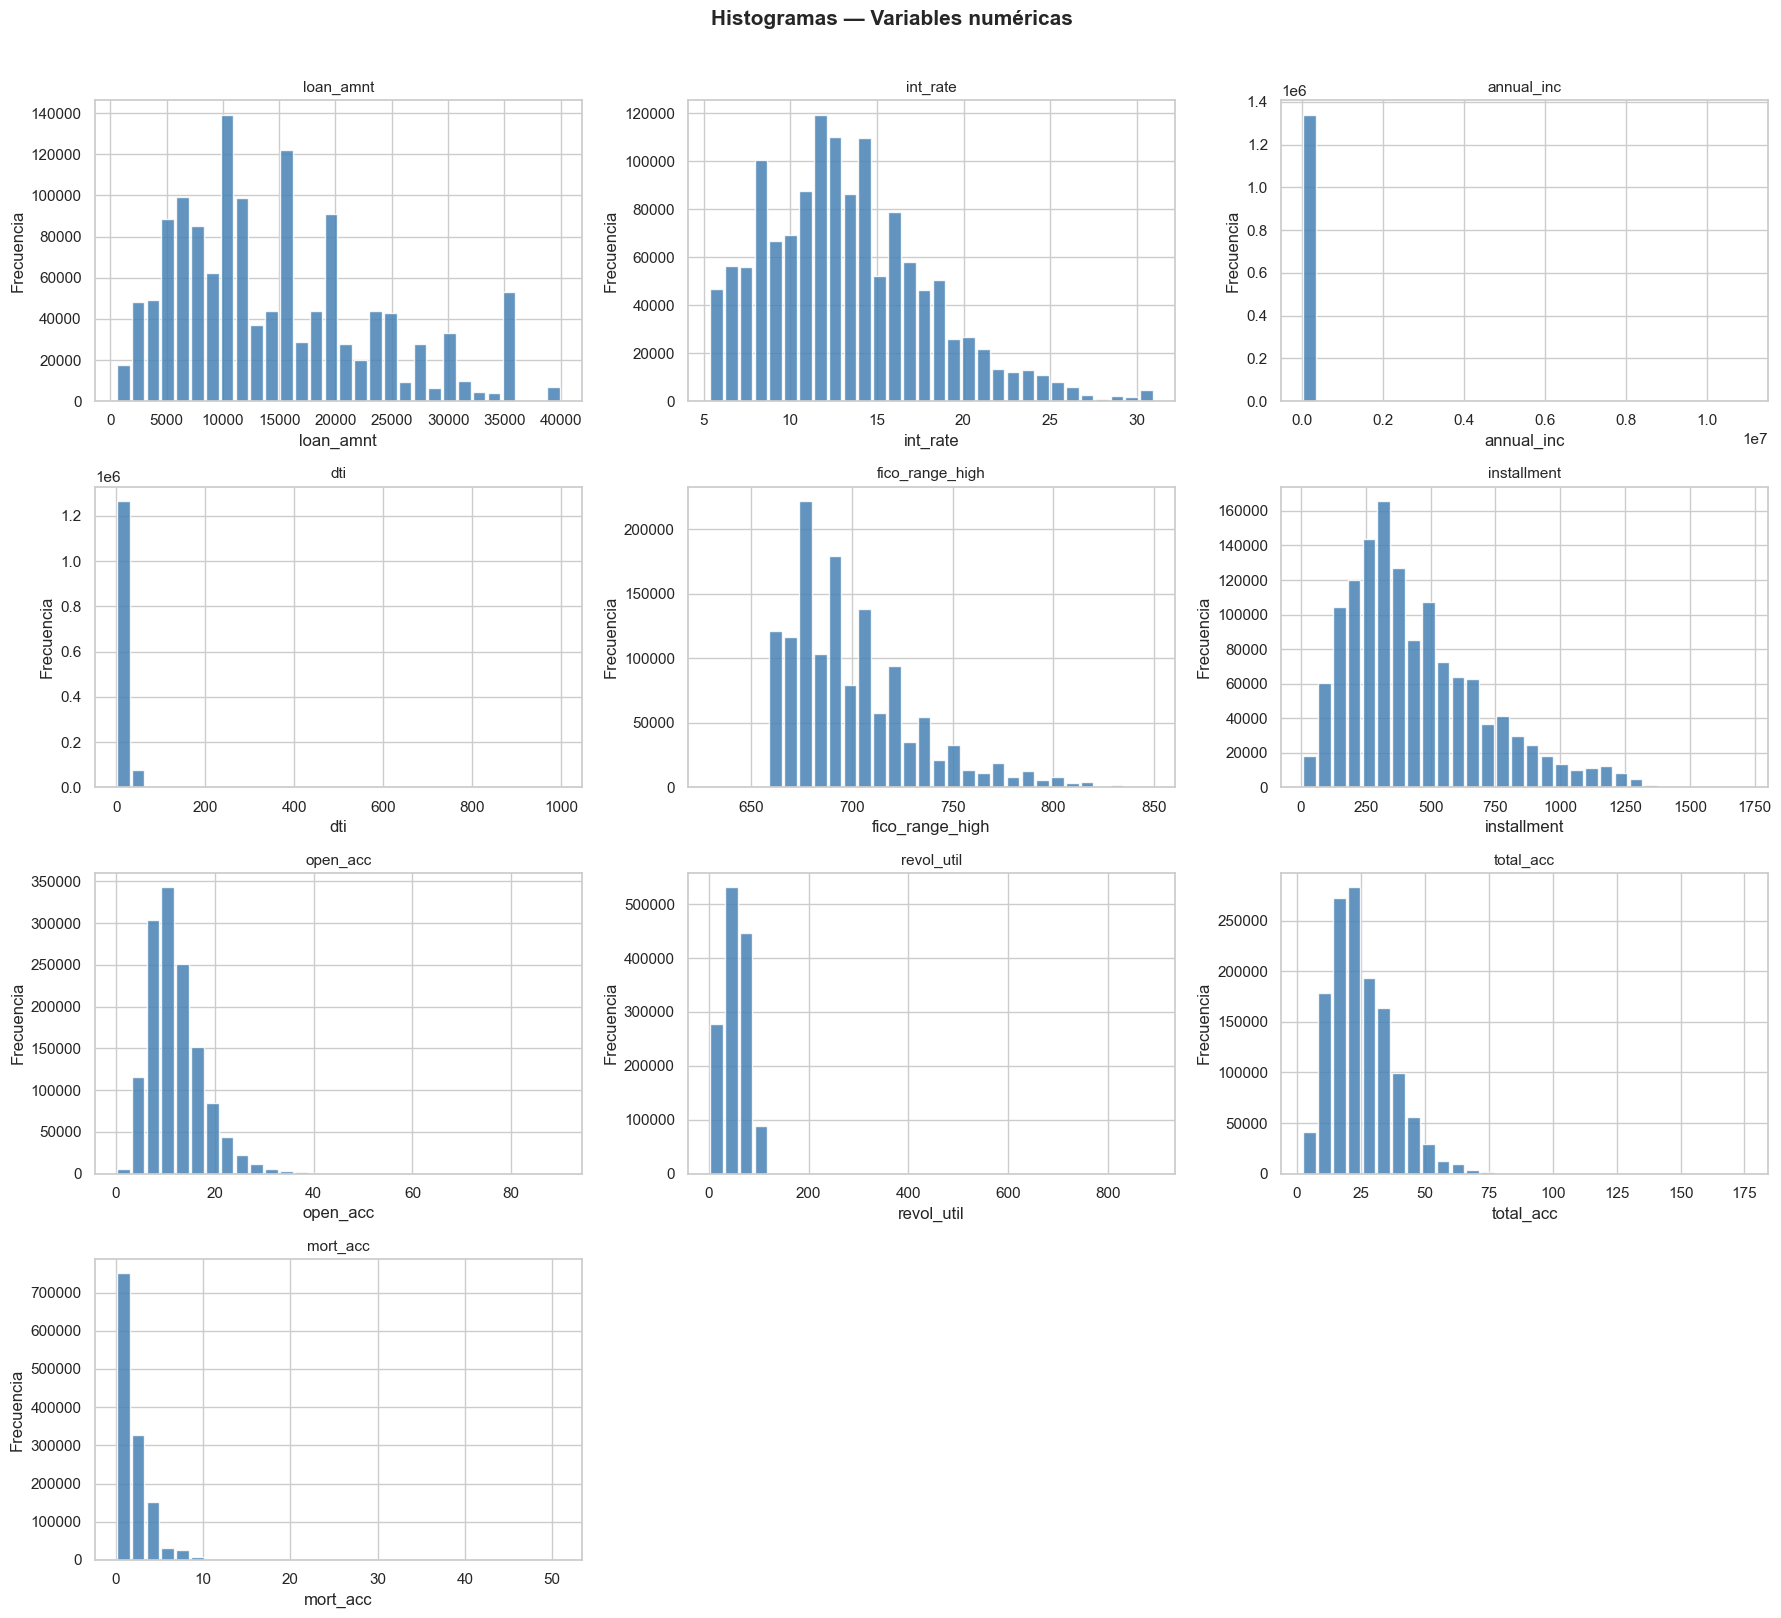

In [ ]:
from pyspark.ml.feature import Bucketizer

ncols = 3
nrows = (len(NUM_COLS) + ncols - 1) // ncols
N_BINS = 30

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    try:
        quantiles = sdf.approxQuantile(col, [0.01, 0.99], 0.01)
        mn, mx = quantiles[0], quantiles[1]
        if mn is None or mx is None or mn == mx:
            axes[i].set_title(f'{col} (sin datos)', fontsize=11)
            continue
        step   = (mx - mn) / N_BINS
        splits = [mn + step * j for j in range(N_BINS + 1)]
        splits[0]  = float('-inf')
        splits[-1] = float('inf')
        bucketizer = Bucketizer(splits=splits, inputCol=col, outputCol='bucket', handleInvalid='skip')
        bucketed   = bucketizer.transform(sdf.select(col).filter(F.col(col).isNotNull()))
        hist_data  = bucketed.groupBy('bucket').count().orderBy('bucket').collect()
        bin_indices = [int(r['bucket']) for r in hist_data]
        bin_counts  = [r['count'] for r in hist_data]
        bin_centers = [mn + step * (idx + 0.5) for idx in bin_indices]
        axes[i].bar(bin_centers, bin_counts, width=step * 0.85,
                    color='steelblue', edgecolor='white', alpha=0.85)
        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')
    except Exception as e:
        axes[i].set_title(f'{col} (error)', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas — Variables numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Boxplots — Variables numéricas

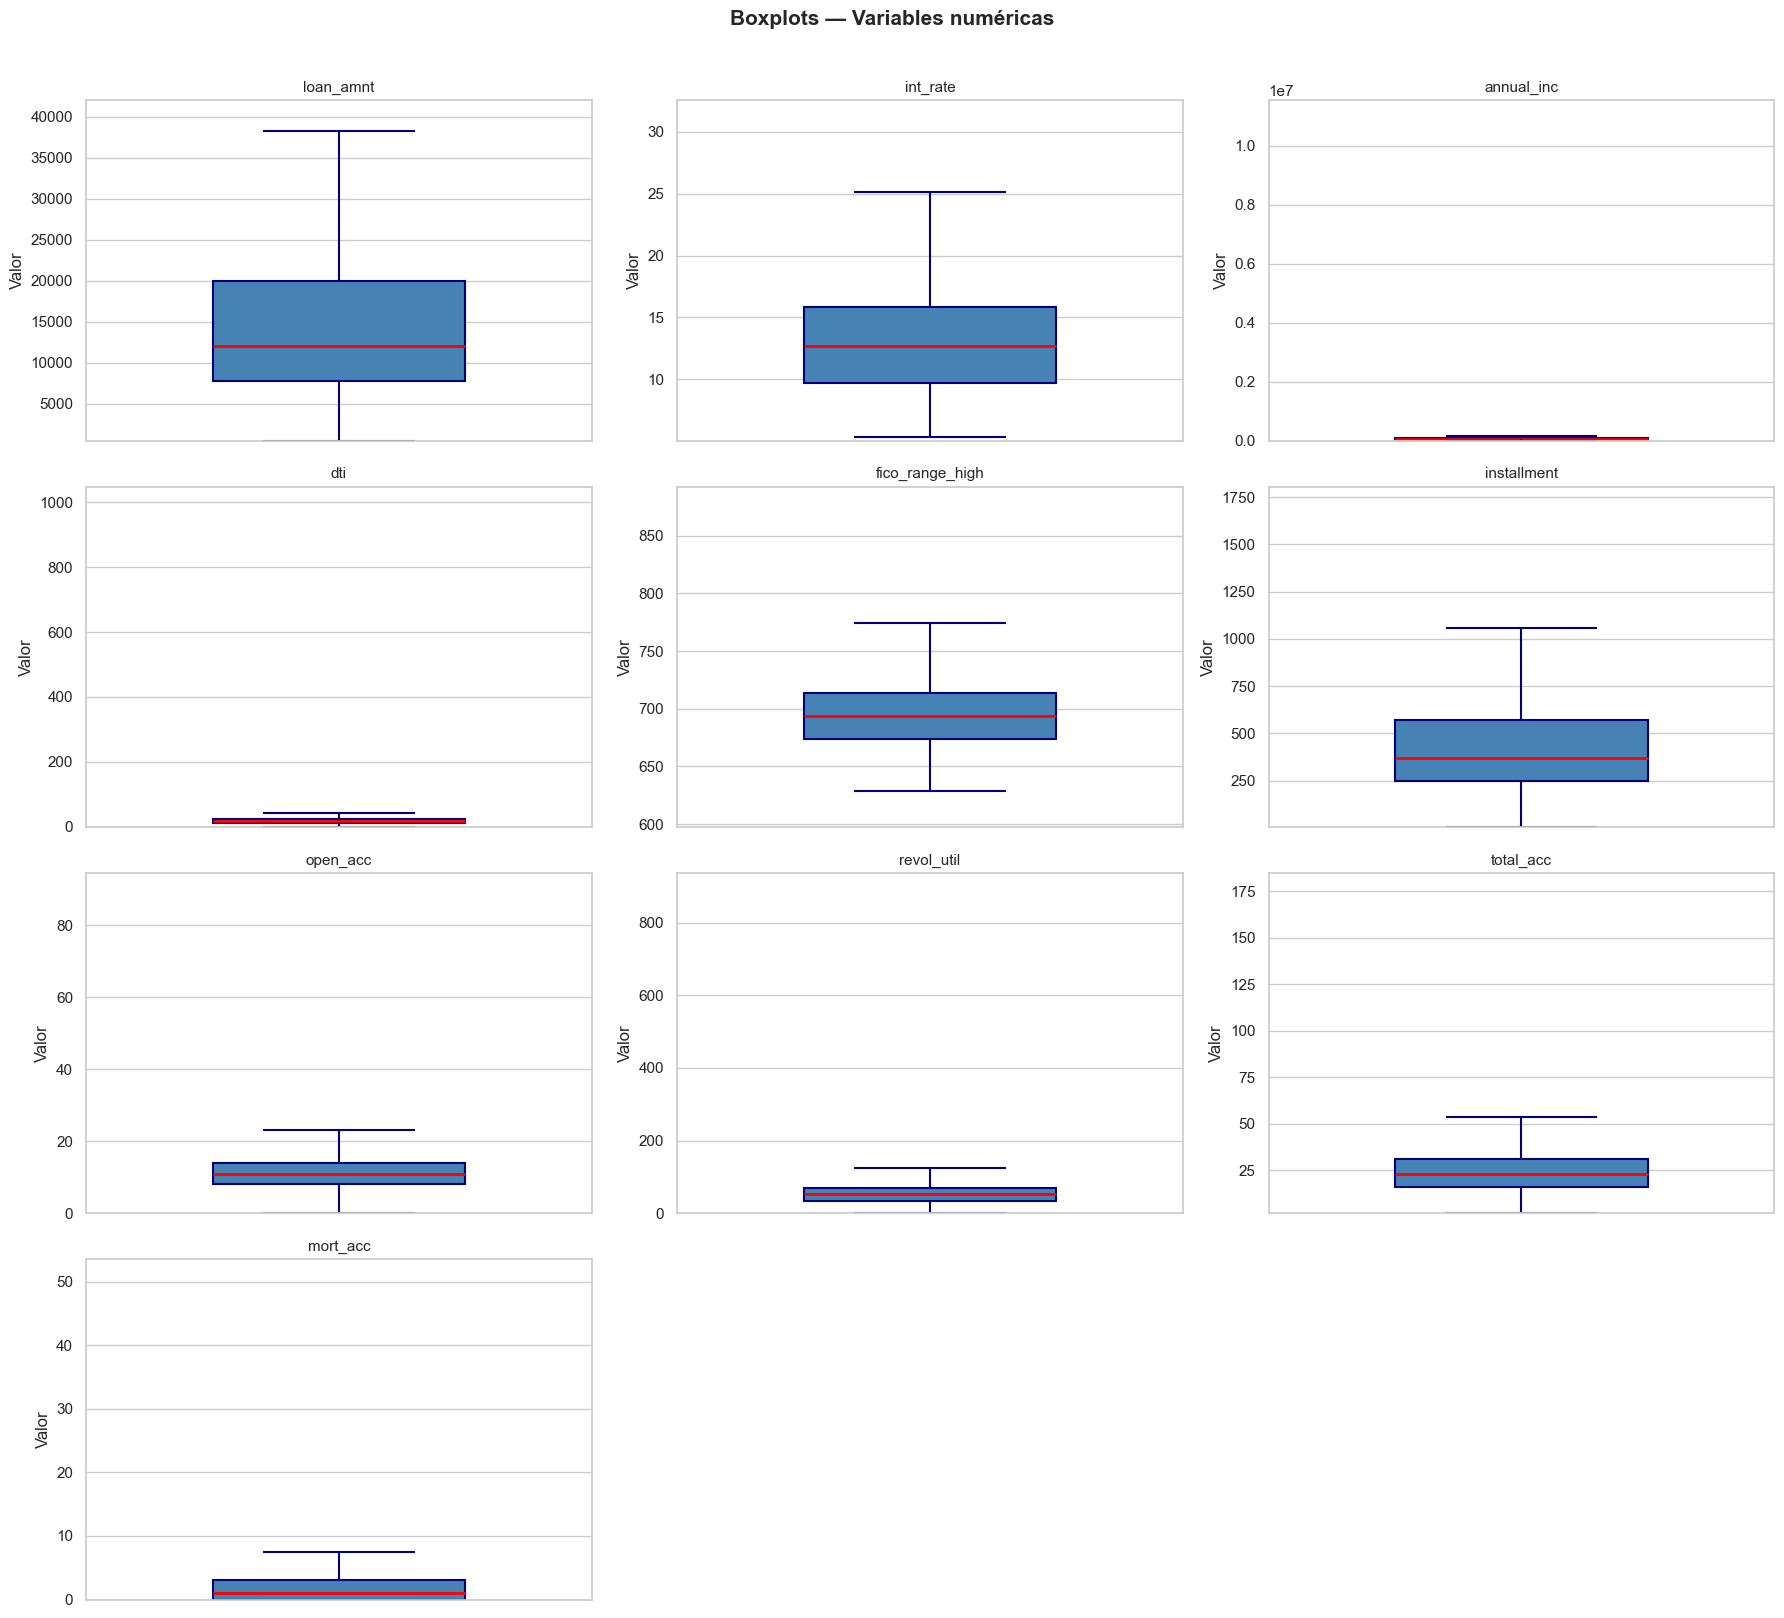

In [ ]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    try:
        q1, median, q3 = sdf.approxQuantile(col, [0.25, 0.50, 0.75], 0.01)
        mn  = sdf.agg(F.min(col)).collect()[0][0] or 0
        mx  = sdf.agg(F.max(col)).collect()[0][0] or 0
        iqr = q3 - q1
        wl  = max(mn, q1 - 1.5 * iqr)
        wh  = min(mx, q3 + 1.5 * iqr)
        ax  = axes[i]
        box = plt.Rectangle((0.25, q1), 0.5, q3 - q1,
                              facecolor='steelblue', edgecolor='navy', linewidth=1.5)
        ax.add_patch(box)
        ax.hlines(median, 0.25, 0.75, colors='red',  linewidth=2)
        ax.vlines(0.5, wl, q1,        colors='navy', linewidth=1.5)
        ax.vlines(0.5, q3, wh,        colors='navy', linewidth=1.5)
        ax.hlines([wl, wh], 0.35, 0.65, colors='navy', linewidth=1.5)
        ax.set_xlim(0, 1)
        ax.set_ylim(mn * 0.95 if mn > 0 else mn * 1.05,
                    mx * 1.05 if mx > 0 else mx * 0.95)
        ax.set_title(col, fontsize=11)
        ax.set_xticks([])
        ax.set_ylabel('Valor')
    except Exception as e:
        axes[i].set_title(f'{col} (error)', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Variables numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Variables categóricas


=== purpose ===
  Missing: 0 (0.00%)
    debt_consolidation: 780,321 (58.00%)
    credit_card: 295,279 (21.95%)
    home_improvement: 87,504 (6.50%)
    other: 77,875 (5.79%)
    major_purchase: 29,425 (2.19%)
    medical: 15,554 (1.16%)
    small_business: 15,416 (1.15%)
    car: 14,585 (1.08%)
    moving: 9,480 (0.70%)
    vacation: 9,065 (0.67%)
    house: 7,253 (0.54%)
    wedding: 2,294 (0.17%)
    renewable_energy: 933 (0.07%)
    educational: 326 (0.02%)


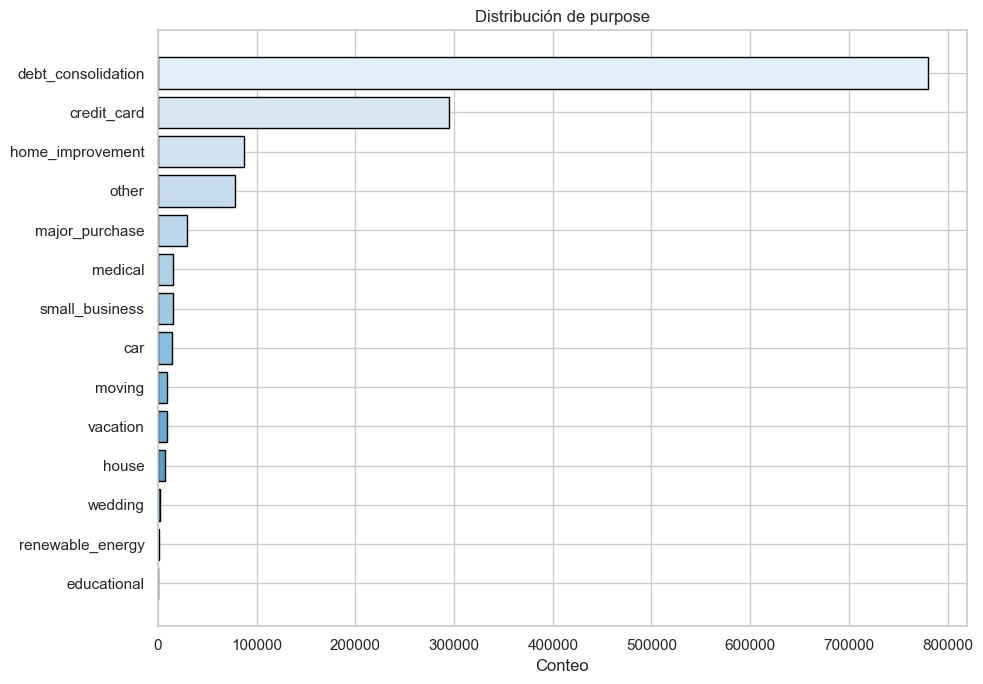


=== home_ownership ===
  Missing: 0 (0.00%)
    MORTGAGE: 665,579 (49.47%)
    RENT: 534,421 (39.72%)
    OWN: 144,832 (10.77%)
    ANY: 286 (0.02%)
    OTHER: 144 (0.01%)
    NONE: 48 (0.00%)


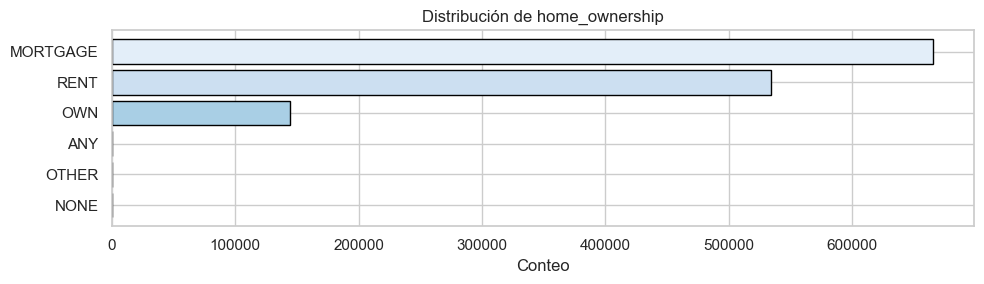


=== verification_status ===
  Missing: 0 (0.00%)
    Source Verified: 521,273 (38.75%)
    Verified: 418,336 (31.10%)
    Not Verified: 405,701 (30.16%)


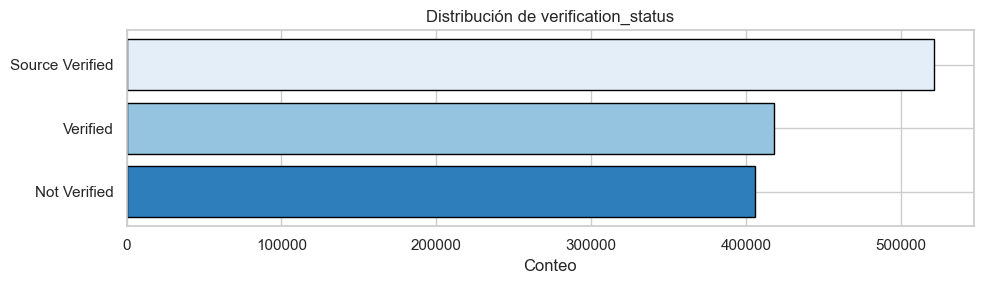


=== grade ===
  Missing: 0 (0.00%)
    B: 392,741 (29.19%)
    C: 381,686 (28.37%)
    A: 235,090 (17.47%)
    D: 200,953 (14.94%)
    E: 93,650 (6.96%)
    F: 32,058 (2.38%)
    G: 9,132 (0.68%)


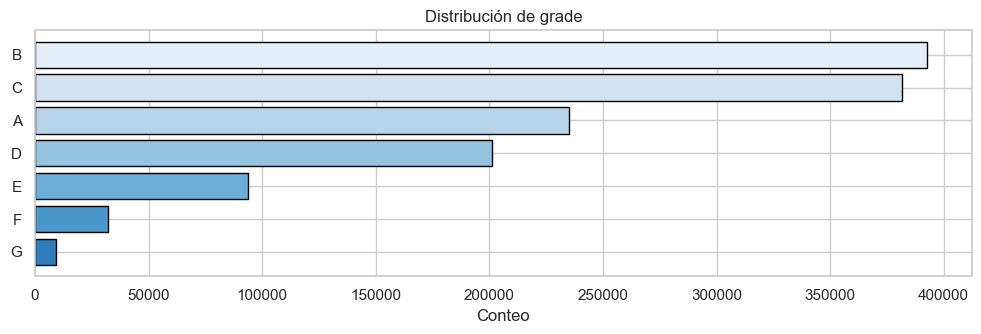


=== term ===
  Missing: 0 (0.00%)
     36 months: 1,020,743 (75.87%)
     60 months: 324,567 (24.13%)


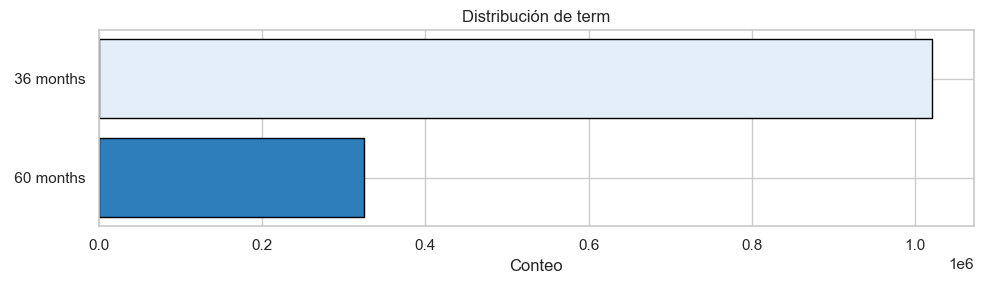

In [ ]:
CAT_COLS = ['purpose', 'home_ownership', 'verification_status', 'grade', 'term']
CAT_COLS = [c for c in CAT_COLS if c in sdf.columns]

for col in CAT_COLS:
    print(f'\n=== {col} ===')
    freq_rows  = sdf.groupBy(col).count() \
                    .withColumn('pct', F.round(F.col('count') / n_valid * 100, 2)) \
                    .orderBy(F.col('count').desc()).collect()
    null_count = sdf.filter(F.col(col).isNull()).count()
    print(f'  Missing: {null_count:,} ({null_count/n_valid*100:.2f}%)')
    cats = [str(r[col]) for r in freq_rows]
    cnts = [r['count'] for r in freq_rows]
    for c, cnt in zip(cats, cnts):
        print(f'    {c}: {cnt:,} ({cnt/n_valid*100:.2f}%)')

    fig, ax = plt.subplots(figsize=(10, max(3, len(cats) * 0.5)))
    colors   = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(cats)))
    ax.barh(cats[::-1], cnts[::-1], color=colors, edgecolor='black')
    ax.set_title(f'Distribución de {col}', fontsize=12)
    ax.set_xlabel('Conteo')
    plt.tight_layout()
    plt.savefig(f'plot_cat_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

### 3.6 Análisis bidimensional — Numéricas vs default

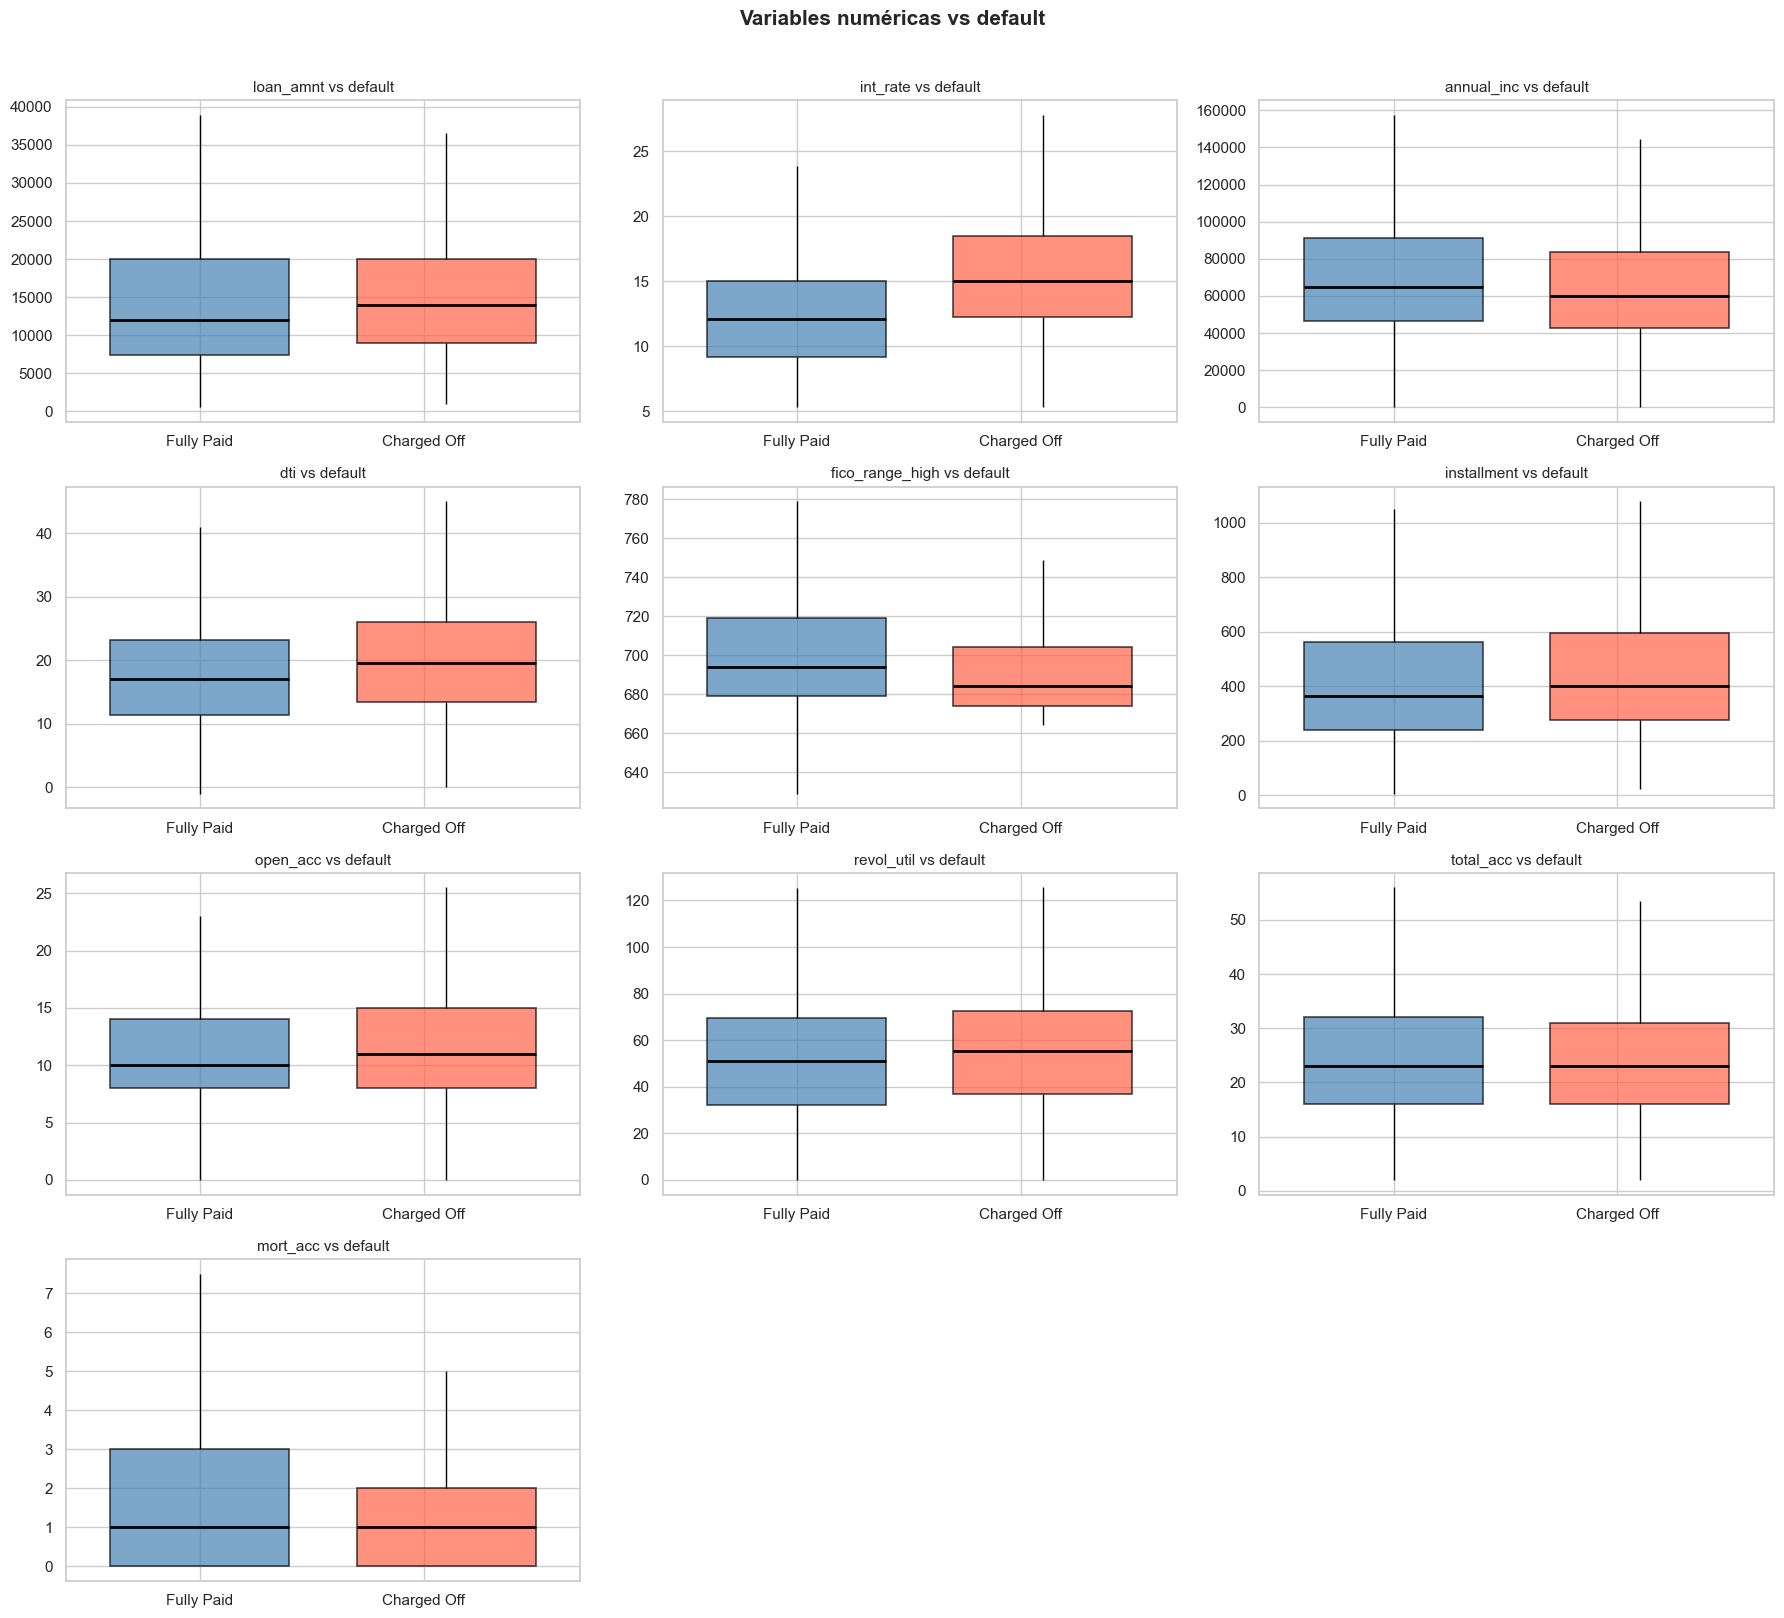

In [ ]:
# Boxplots por clase
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()
colors_cls = {0: 'steelblue', 1: 'tomato'}

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    for j, cls in enumerate([0, 1]):
        sub = sdf.filter(F.col('default') == cls)
        try:
            q1, med, q3 = sub.approxQuantile(col, [0.25, 0.50, 0.75], 0.01)
            iqr = q3 - q1
            mn  = sub.agg(F.min(col)).collect()[0][0] or 0
            mx  = sub.agg(F.max(col)).collect()[0][0] or 0
            wl  = max(mn, q1 - 1.5 * iqr)
            wh  = min(mx, q3 + 1.5 * iqr)
            x0, x1 = j * 0.55 + 0.05, j * 0.55 + 0.45
            xm = (x0 + x1) / 2
            box = plt.Rectangle((x0, q1), x1 - x0, q3 - q1,
                                  facecolor=colors_cls[cls], alpha=0.7,
                                  edgecolor='black', linewidth=1.2)
            ax.add_patch(box)
            ax.hlines(med, x0, x1, colors='black', linewidth=2)
            ax.vlines(xm, wl, q1,  colors='black', linewidth=1)
            ax.vlines(xm, q3, wh,  colors='black', linewidth=1)
        except:
            pass
    ax.set_xlim(-0.05, 1.1)
    ax.set_xticks([0.25, 0.75])
    ax.set_xticklabels(['Fully Paid', 'Charged Off'])
    ax.set_title(f'{col} vs default', fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables numéricas vs default', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_bivar_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Diferencia de medias por clase
print('=== Diferencia de medias por clase ===')
print(f'\n{"Variable":<25} {"Mean Fully Paid":>16} {"Mean Charged Off":>16} {"Diferencia":>12}')
print('-' * 72)
for col in NUM_COLS:
    try:
        means  = sdf.groupBy('default').agg(F.mean(col).alias('mean')).orderBy('default').collect()
        mean_0 = means[0]['mean'] if len(means) > 0 else 0
        mean_1 = means[1]['mean'] if len(means) > 1 else 0
        diff   = (mean_1 - mean_0) if (mean_0 and mean_1) else 0
        signo  = '▲' if diff > 0 else '▼'
        print(f'{col:<25} {mean_0:>16.4f} {mean_1:>16.4f} {signo} {abs(diff):>10.4f}')
    except Exception as e:
        print(f'{col:<25} ERROR: {str(e)[:40]}')

=== Diferencia de medias por clase ===

Variable                   Mean Fully Paid Mean Charged Off   Diferencia
------------------------------------------------------------------------
loan_amnt                       14134.3698       15565.0554 ▲  1430.6856
int_rate                           12.6233          15.7107 ▲     3.0874
annual_inc                      77705.9455       70400.7433 ▼  7305.2022
dti                                17.8116          20.1712 ▲     2.3596
fico_range_high                   702.2641         691.8502 ▼    10.4139
installment                       431.3232         465.1480 ▲    33.8248
open_acc                           11.5168          11.9013 ▲     0.3845
revol_util                         51.0747          54.7584 ▲     3.6838
total_acc                          25.0486          24.7094 ▼     0.3392
mort_acc                            1.7465           1.3710 ▼     0.3754


### 3.7 Categóricas vs default


=== purpose — Tasa de default ===
+------------------+--------------+
|purpose           |default_rate_%|
+------------------+--------------+
|small_business    |29.71         |
|renewable_energy  |23.69         |
|moving            |23.35         |
|house             |21.88         |
|medical           |21.78         |
|debt_consolidation|21.15         |
|other             |21.04         |
|vacation          |19.17         |
|major_purchase    |18.6          |
|home_improvement  |17.72         |
|educational       |17.18         |
|credit_card       |16.93         |
|car               |14.68         |
|wedding           |12.16         |
+------------------+--------------+



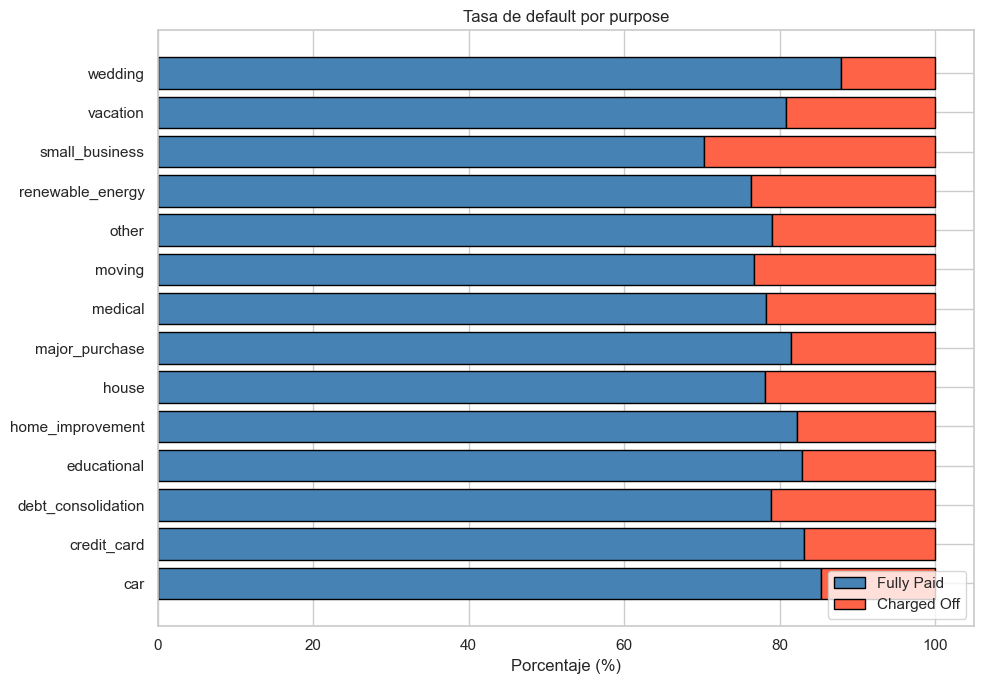


=== home_ownership — Tasa de default ===
+--------------+--------------+
|home_ownership|default_rate_%|
+--------------+--------------+
|RENT          |23.22         |
|OWN           |20.62         |
|ANY           |19.58         |
|OTHER         |18.75         |
|MORTGAGE      |17.21         |
|NONE          |14.58         |
+--------------+--------------+



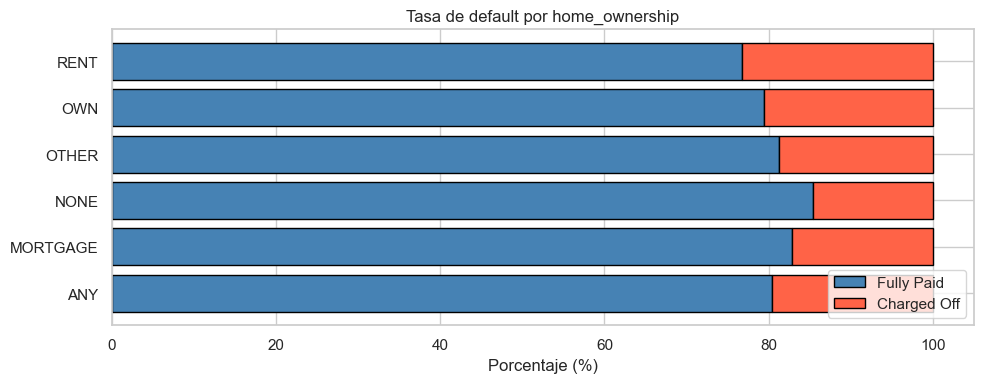


=== verification_status — Tasa de default ===
+-------------------+--------------+
|verification_status|default_rate_%|
+-------------------+--------------+
|Verified           |23.85         |
|Source Verified    |20.95         |
|Not Verified       |14.67         |
+-------------------+--------------+



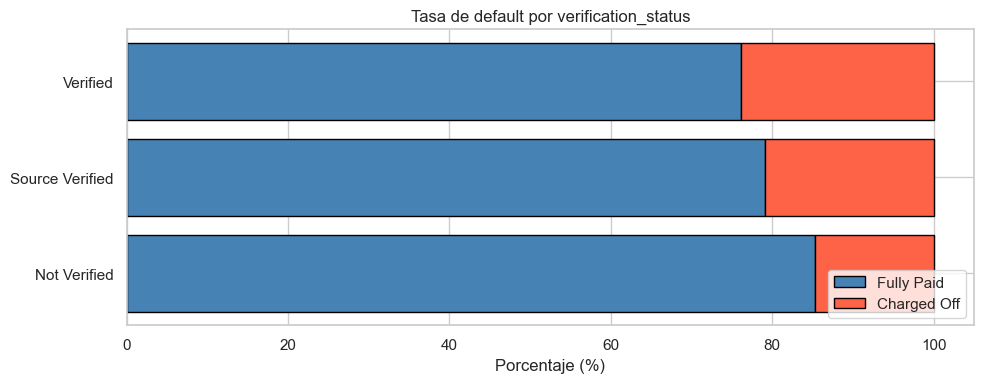


=== grade — Tasa de default ===
+-----+--------------+
|grade|default_rate_%|
+-----+--------------+
|G    |49.93         |
|F    |45.2          |
|E    |38.48         |
|D    |30.38         |
|C    |22.44         |
|B    |13.39         |
|A    |6.04          |
+-----+--------------+



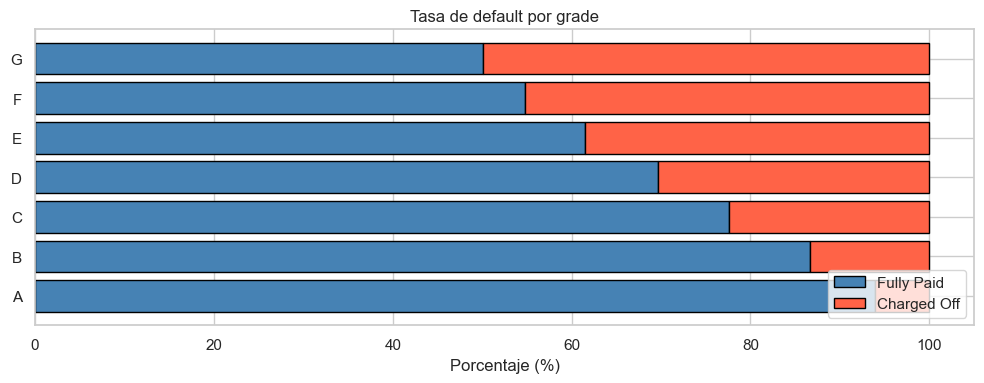


=== term — Tasa de default ===
+----------+--------------+
|term      |default_rate_%|
+----------+--------------+
| 60 months|32.45         |
| 36 months|15.99         |
+----------+--------------+



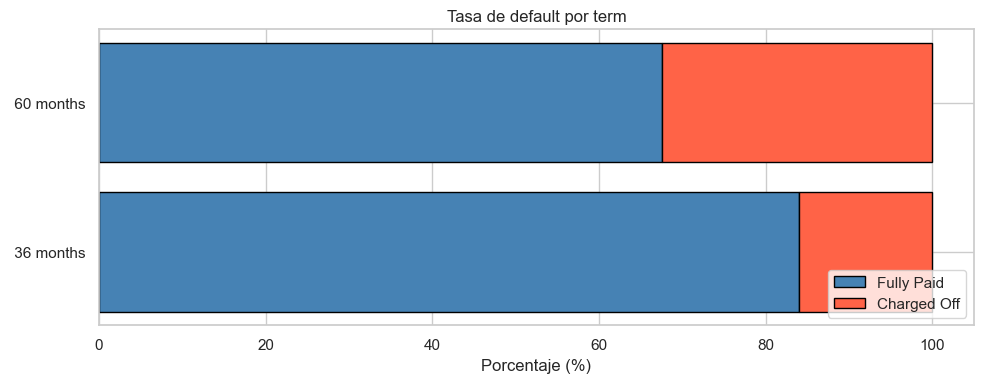

In [ ]:
for col in CAT_COLS:
    print(f'\n=== {col} — Tasa de default ===')
    ct             = sdf.groupBy(col, 'default').count()
    total_per_cat  = sdf.groupBy(col).count().withColumnRenamed('count', 'total')
    ct             = ct.join(total_per_cat, on=col)
    ct_default     = ct.filter(F.col('default') == 1) \
                       .withColumn('default_rate_%', F.round(F.col('count') / F.col('total') * 100, 2)) \
                       .select(col, 'default_rate_%') \
                       .orderBy(F.col('default_rate_%').desc())
    ct_default.show(truncate=False)

    rows_ct  = sdf.groupBy(col, 'default').count().orderBy(col, 'default').collect()
    cat_vals = sorted(list(set(str(r[col]) for r in rows_ct if r[col] is not None)))
    dict_0   = {str(r[col]): r['count'] for r in rows_ct if r['default'] == 0}
    dict_1   = {str(r[col]): r['count'] for r in rows_ct if r['default'] == 1}
    cnt0     = [dict_0.get(c, 0) for c in cat_vals]
    cnt1     = [dict_1.get(c, 0) for c in cat_vals]
    totals   = [a + b for a, b in zip(cnt0, cnt1)]
    pct0     = [a / t * 100 if t > 0 else 0 for a, t in zip(cnt0, totals)]
    pct1     = [b / t * 100 if t > 0 else 0 for b, t in zip(cnt1, totals)]

    fig, ax = plt.subplots(figsize=(10, max(4, len(cat_vals) * 0.5)))
    y = np.arange(len(cat_vals))
    ax.barh(y, pct0, color='steelblue', edgecolor='black', label='Fully Paid')
    ax.barh(y, pct1, left=pct0, color='tomato', edgecolor='black', label='Charged Off')
    ax.set_yticks(y)
    ax.set_yticklabels(cat_vals)
    ax.set_xlabel('Porcentaje (%)')
    ax.set_title(f'Tasa de default por {col}', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(f'plot_bivar_cat_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

### 3.8 Matriz de correlaciones

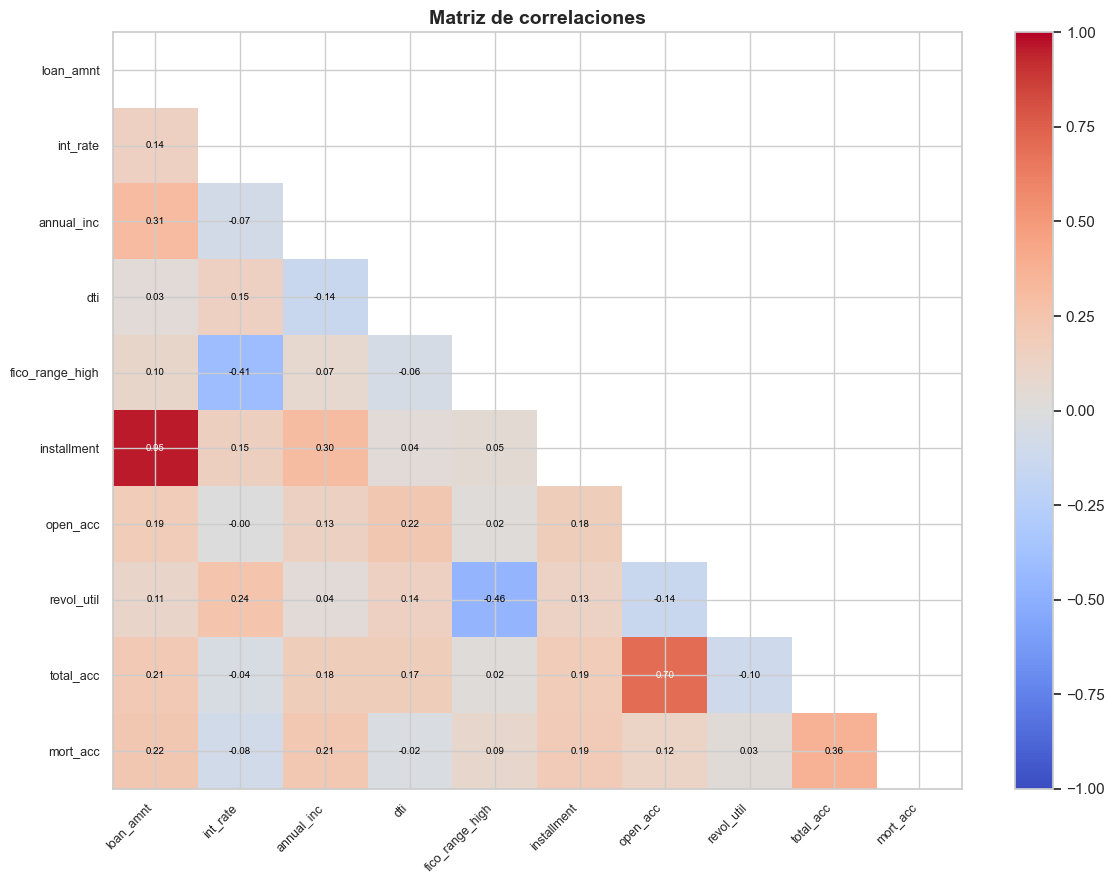


Pares con |r| > 0.7:
  loan_amnt — installment: r = 0.953
  open_acc — total_acc: r = 0.701


In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

sdf_corr = sdf.select(NUM_COLS)
for col in NUM_COLS:
    median_val = sdf_corr.approxQuantile(col, [0.5], 0.01)[0]
    sdf_corr   = sdf_corr.fillna({col: median_val})

assembler_corr = VectorAssembler(inputCols=NUM_COLS, outputCol='features_corr')
sdf_vec        = assembler_corr.transform(sdf_corr)
corr_matrix    = Correlation.corr(sdf_vec, 'features_corr').collect()[0][0].toArray()

fig, ax = plt.subplots(figsize=(12, 9))
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_masked = np.where(mask, np.nan, corr_matrix)
im = ax.imshow(corr_masked, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(NUM_COLS)))
ax.set_yticks(range(len(NUM_COLS)))
ax.set_xticklabels(NUM_COLS, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(NUM_COLS, fontsize=9)
for i in range(len(NUM_COLS)):
    for j in range(len(NUM_COLS)):
        if not mask[i, j]:
            ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if abs(corr_matrix[i, j]) > 0.7 else 'black')
ax.set_title('Matriz de correlaciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPares con |r| > 0.7:')
found = False
for i in range(len(NUM_COLS)):
    for j in range(i + 1, len(NUM_COLS)):
        r = corr_matrix[i, j]
        if abs(r) > 0.7:
            print(f'  {NUM_COLS[i]} — {NUM_COLS[j]}: r = {r:.3f}')
            found = True
if not found:
    print('  No se encontraron pares con |r| > 0.7')

### 3.9 Valores faltantes

Calculando valores faltantes...
Columnas con valores faltantes: 105

Columna                                            Nulos    Pct_%  Plan
-----------------------------------------------------------------------------------------------
member_id                                      1,345,310  100.00%  ELIMINAR
next_pymnt_d                                   1,345,310  100.00%  ELIMINAR
orig_projected_additional_accrued_interest     1,341,551   99.72%  ELIMINAR
hardship_type                                  1,339,556   99.57%  ELIMINAR
hardship_reason                                1,339,556   99.57%  ELIMINAR
hardship_status                                1,339,556   99.57%  ELIMINAR
deferral_term                                  1,339,556   99.57%  ELIMINAR
hardship_amount                                1,339,556   99.57%  ELIMINAR
hardship_start_date                            1,339,556   99.57%  ELIMINAR
hardship_end_date                              1,339,556   99.57%  ELIMINAR
pay

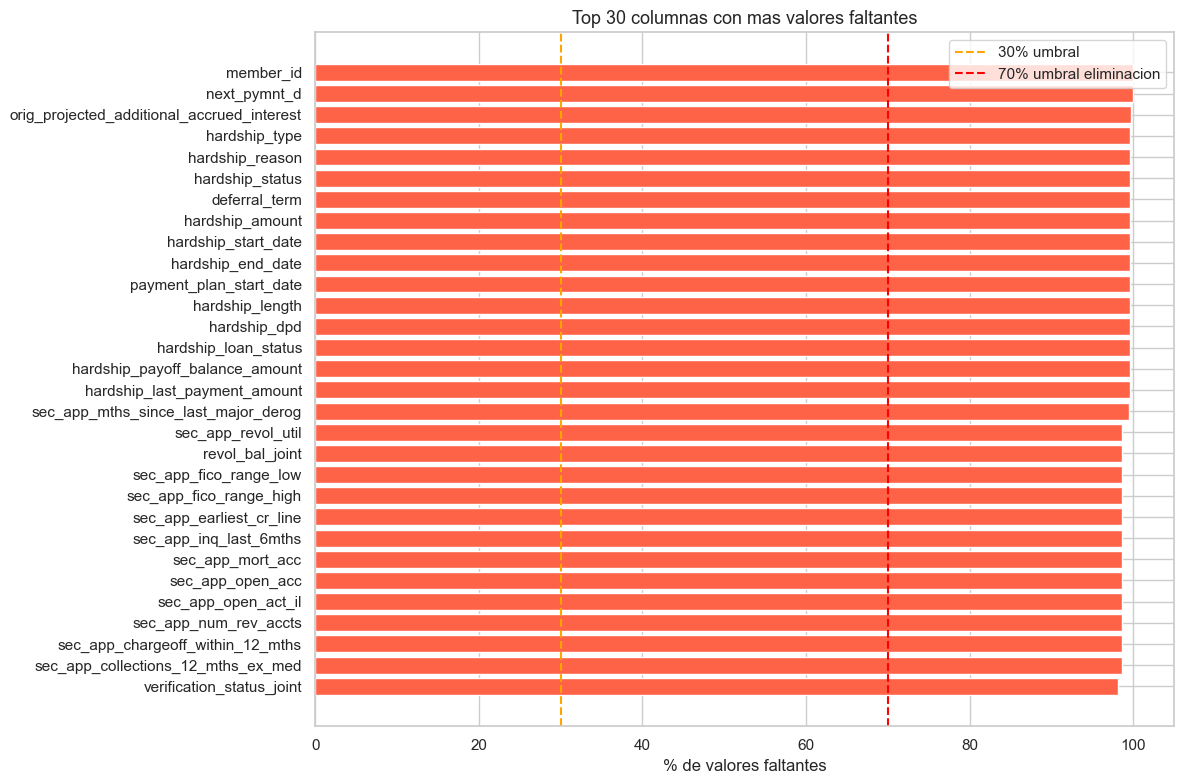

In [ ]:
print('Calculando valores faltantes...')
null_exprs  = [F.sum(F.col(c).isNull().cast(IntegerType())).alias(c) for c in sdf.columns]
null_counts = sdf.select(null_exprs).collect()[0].asDict()

missing_rows = [
    (col, int(cnt), round(cnt / n_valid * 100, 2))
    for col, cnt in null_counts.items() if cnt > 0
]
missing_rows.sort(key=lambda x: -x[2])

def plan(pct):
    if pct > 70:   return 'ELIMINAR'
    elif pct > 30: return 'Imputar / Missing'
    else:          return 'Imputar mediana/moda'

print(f'Columnas con valores faltantes: {len(missing_rows)}')
print(f'\n{"Columna":<45} {"Nulos":>10} {"Pct_%":>8}  {"Plan"}')
print('-' * 95)
for col, nulos, pct in missing_rows:
    print(f'{col:<45} {nulos:>10,} {pct:>7.2f}%  {plan(pct)}')

top30      = missing_rows[:30]
cols_plot  = [r[0] for r in top30]
pcts_plot  = [r[2] for r in top30]
bar_colors = ['tomato' if p > 70 else 'orange' if p > 30 else 'steelblue' for p in pcts_plot]

plt.figure(figsize=(12, 8))
plt.barh(cols_plot[::-1], pcts_plot[::-1], color=bar_colors[::-1])
plt.axvline(30, color='orange', linestyle='--', label='30% umbral')
plt.axvline(70, color='red',    linestyle='--', label='70% umbral eliminacion')
plt.xlabel('% de valores faltantes')
plt.title('Top 30 columnas con mas valores faltantes', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('plot_missing_bar.png', dpi=150, bbox_inches='tight')
plt.show()

3.10 Resumen ejecutivo del EDA
Calidad de los datos: El dataset contiene 1,345,310 registros válidos con 151 columnas. Se identificaron 105 columnas con valores faltantes, de las cuales 26 superan el 70% de nulos y deben eliminarse (columnas hardship, sec_app, settlement). Las variables seleccionadas para modelado tienen nulos manejables: mort_acc (3.51%), revol_util (0.06%), dti (0.03%).

Variables más prometedoras: grade, int_rate, term_months y annual_inc son las más discriminativas. La tasa de default varía marcadamente por grado crediticio y plazo del préstamo.

Problemas detectados:

Desbalance: 80% Fully Paid vs 20% Charged Off
Outliers: annual_inc máximo de $10.9M, dti con valor 999
Missing sistemáticos: 26 columnas con >70% nulos
Multicolinealidad: loan_amnt/funded_amnt/funded_amnt_inv altamente correlacionadas
Decisiones para preprocesamiento: Eliminar columnas con >70% nulos. Imputar numéricas con mediana, categóricas con moda. Usar class_weight='balanced' en sklearn. Métricas principales: ROC AUC y F1-score.

## 4. Preprocesamiento y Modelado — scikit-learn

In [ ]:
# Extraer muestra para scikit-learn usando toPandas solo sobre columnas seleccionadas
# Se permite porque scikit-learn opera en memoria local y necesita los datos ahí
FEATURES_SK = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti',
                'open_acc', 'revol_util', 'mort_acc', 'term_months',
                'purpose', 'home_ownership', 'verification_status', 'grade', 'default']
FEATURES_SK = [f for f in FEATURES_SK if f in sdf.columns]

print('Convirtiendo dataset a formato scikit-learn...')
t0     = time.time()
df_sk  = sdf.select(FEATURES_SK).toPandas()  # ✅ permitido para sklearn
t_conv = time.time() - t0
print(f'Conversión completada en {t_conv:.2f}s. Shape: {df_sk.shape}')

Convirtiendo dataset a formato scikit-learn...
Conversión completada en 7.61s. Shape: (1345310, 14)


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

TARGET = 'default'
X      = df_sk.drop(columns=[TARGET])
y      = df_sk[TARGET]

num_features_sk = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features_sk = X.select_dtypes(include=['object']).columns.tolist()
print('Numéricas:', num_features_sk)
print('Categóricas:', cat_features_sk)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor_sk = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features_sk),
    ('cat', categorical_transformer, cat_features_sk)
])

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

# Transformar
t0 = time.time()
X_train_proc = preprocessor_sk.fit_transform(X_train)
X_test_proc  = preprocessor_sk.transform(X_test)
t_prep_sk    = time.time() - t0
print(f'Preprocesamiento sklearn: {t_prep_sk:.2f}s')

Numéricas: ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti', 'open_acc', 'revol_util', 'mort_acc', 'term_months']
Categóricas: ['purpose', 'home_ownership', 'verification_status', 'grade']
Train: 1,076,248 | Test: 269,062
Preprocesamiento sklearn: 3.82s


In [ ]:
import joblib

# GridSearchCV sin Pipeline (requerimiento del proyecto)
param_grid_sk = {
    'n_estimators': [10, 50, 100],
    'max_depth':    [5, 10, 15]
}
rf_sk = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
grid_search = GridSearchCV(
    estimator=rf_sk,
    param_grid=param_grid_sk,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print('Iniciando GridSearchCV scikit-learn...')
t0 = time.time()
grid_search.fit(X_train_proc, y_train)
t_train_sk = time.time() - t0

print(f'\n✅ Entrenamiento sklearn: {t_train_sk:.2f}s ({t_train_sk/60:.1f} min)')
print(f'Mejores parámetros: {grid_search.best_params_}')
print(f'Mejor ROC AUC (CV): {grid_search.best_score_:.4f}')

best_rf_sk = grid_search.best_estimator_

t0 = time.time()
y_pred_sk = best_rf_sk.predict(X_test_proc)
y_prob_sk = best_rf_sk.predict_proba(X_test_proc)[:, 1]
t_pred_sk = time.time() - t0

Iniciando GridSearchCV scikit-learn...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

✅ Entrenamiento sklearn: 319.75s (5.3 min)
Mejores parámetros: {'max_depth': 15, 'n_estimators': 100}
Mejor ROC AUC (CV): 0.7105


=== Métricas scikit-learn ===
  Accuracy:  0.6592
  Precision: 0.3224
  Recall:    0.6418
  F1-score:  0.4292
  ROC AUC:   0.7115

Tiempo predicción: 1.04s

              precision    recall  f1-score   support

  Fully Paid       0.88      0.66      0.76    215350
 Charged Off       0.32      0.64      0.43     53712

    accuracy                           0.66    269062
   macro avg       0.60      0.65      0.59    269062
weighted avg       0.77      0.66      0.69    269062



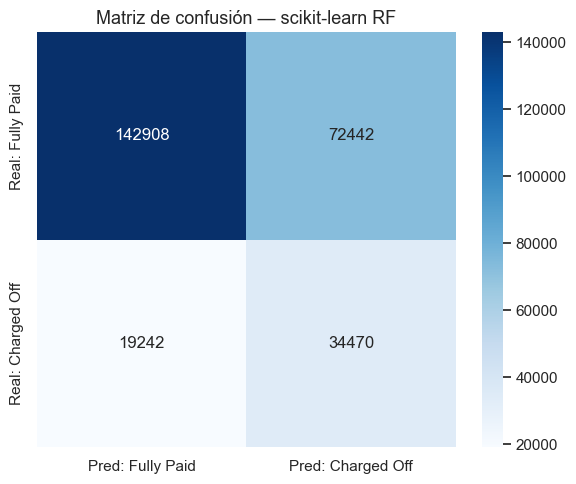

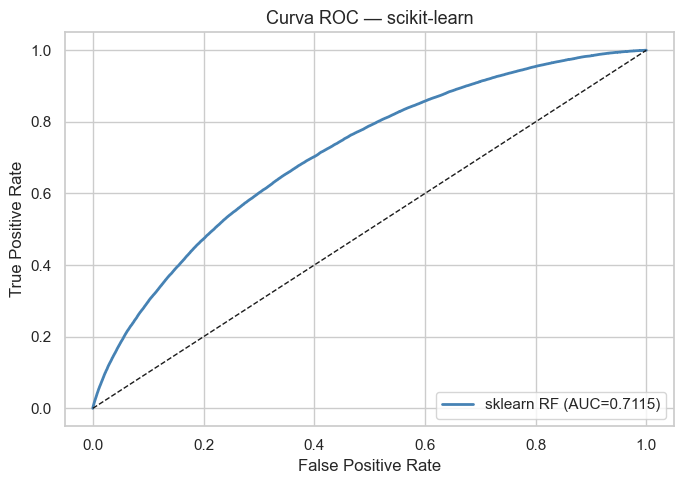

In [ ]:
# Métricas scikit-learn
acc_sk  = accuracy_score(y_test, y_pred_sk)
prec_sk = precision_score(y_test, y_pred_sk)
rec_sk  = recall_score(y_test, y_pred_sk)
f1_sk   = f1_score(y_test, y_pred_sk)
roc_sk  = roc_auc_score(y_test, y_prob_sk)

print('=== Métricas scikit-learn ===')
print(f'  Accuracy:  {acc_sk:.4f}')
print(f'  Precision: {prec_sk:.4f}')
print(f'  Recall:    {rec_sk:.4f}')
print(f'  F1-score:  {f1_sk:.4f}')
print(f'  ROC AUC:   {roc_sk:.4f}')
print(f'\nTiempo predicción: {t_pred_sk:.2f}s')
print('\n' + classification_report(y_test, y_pred_sk, target_names=['Fully Paid', 'Charged Off']))

# Matriz de confusión sklearn
cm_sk = confusion_matrix(y_test, y_pred_sk)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Fully Paid', 'Pred: Charged Off'],
            yticklabels=['Real: Fully Paid', 'Real: Charged Off'])
ax.set_title('Matriz de confusión — scikit-learn RF', fontsize=13)
plt.tight_layout()
plt.savefig('plot_cm_sklearn.png', dpi=150, bbox_inches='tight')
plt.show()

# Curva ROC sklearn
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_prob_sk)
plt.figure(figsize=(7, 5))
plt.plot(fpr_sk, tpr_sk, color='steelblue', lw=2, label=f'sklearn RF (AUC={roc_sk:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — scikit-learn', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_roc_sklearn.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Preprocesamiento y Modelado — PySpark

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, Imputer, StandardScaler
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.classification import RandomForestClassifier as SparkRF
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

NUM_FEATURES = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc',
                'dti', 'open_acc', 'revol_util', 'mort_acc', 'term_months']
CAT_FEATURES = ['purpose', 'home_ownership', 'verification_status', 'grade']
NUM_FEATURES = [c for c in NUM_FEATURES if c in sdf.columns]
CAT_FEATURES = [c for c in CAT_FEATURES if c in sdf.columns]

imputer   = Imputer(inputCols=NUM_FEATURES,
                    outputCols=[f'{c}_imp' for c in NUM_FEATURES], strategy='median')
indexers  = [StringIndexer(inputCol=c, outputCol=f'{c}_idx', handleInvalid='keep') for c in CAT_FEATURES]
encoders  = [OneHotEncoder(inputCol=f'{c}_idx', outputCol=f'{c}_ohe') for c in CAT_FEATURES]
assembler = VectorAssembler(
    inputCols=[f'{c}_imp' for c in NUM_FEATURES] + [f'{c}_ohe' for c in CAT_FEATURES],
    outputCol='features_raw', handleInvalid='skip'
)
scaler = StandardScaler(inputCol='features_raw', outputCol='features', withMean=True, withStd=True)
prep_pipeline = SparkPipeline(stages=[imputer] + indexers + encoders + [assembler, scaler])

# Split 80/20
train_sdf, test_sdf = sdf.randomSplit([0.8, 0.2], seed=42)
n_train = train_sdf.count()
n_test  = test_sdf.count()
print(f'Train: {n_train:,} | Test: {n_test:,}')

print('Ajustando pipeline...')
t0 = time.time()
prep_model        = prep_pipeline.fit(train_sdf)
train_transformed = prep_model.transform(train_sdf).select('features', 'default').withColumnRenamed('default', 'label')
test_transformed  = prep_model.transform(test_sdf).select('features', 'default').withColumnRenamed('default', 'label')
t_prep_sp         = time.time() - t0
print(f'Preprocesamiento Spark: {t_prep_sp:.2f}s')

# ✅ OBLIGATORIO: cachear antes del entrenamiento
train_transformed = train_transformed.repartition(50).persist(StorageLevel.MEMORY_AND_DISK)
test_transformed  = test_transformed.persist(StorageLevel.MEMORY_AND_DISK)
_ = train_transformed.count()
_ = test_transformed.count()
print('Datos cacheados.')

Train: 1,076,738 | Test: 268,572
Ajustando pipeline...
Preprocesamiento Spark: 17.43s
Datos cacheados.


In [ ]:
rf_sp = SparkRF(
    featuresCol='features', labelCol='label', seed=42,
    cacheNodeIds=True, maxMemoryInMB=512
)

# ParamGridBuilder — NO se permiten loops manuales
param_grid_sp = ParamGridBuilder() \
    .addGrid(rf_sp.numTrees, [10, 50, 100]) \
    .addGrid(rf_sp.maxDepth, [5, 10, 15]) \
    .build()

print(f'Combinaciones: {len(param_grid_sp)} x 3 folds = {len(param_grid_sp)*3} fits')

evaluator = BinaryClassificationEvaluator(
    labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC'
)
cv = CrossValidator(
    estimator=rf_sp,
    estimatorParamMaps=param_grid_sp,
    evaluator=evaluator,
    numFolds=3,
    seed=42,
    parallelism=3
)

print('Iniciando entrenamiento PySpark...')
print('⚠️  Puede tardar varios minutos.')

t0 = time.time()
cv_model    = cv.fit(train_transformed)
t_train_sp  = time.time() - t0

best_model  = cv_model.bestModel
best_auc_cv = max(cv_model.avgMetrics)
print(f'\n✅ Entrenamiento Spark: {t_train_sp:.2f}s ({t_train_sp/60:.1f} min)')
print(f'Mejor ROC AUC (CV): {best_auc_cv:.4f}')
print(f'numTrees: {best_model.getNumTrees}')
print(f'maxDepth: {best_model.getOrDefault("maxDepth")}')

Combinaciones: 9 x 3 folds = 27 fits
Iniciando entrenamiento PySpark...
⚠️  Puede tardar varios minutos.

✅ Entrenamiento Spark: 2081.52s (34.7 min)
Mejor ROC AUC (CV): 0.7106
numTrees: 100
maxDepth: 15


=== Métricas PySpark ===
  Accuracy:  0.8027
  Precision: 0.7600
  Recall:    0.8027
  F1-score:  0.7318
  ROC AUC:   0.7118

Tiempo predicción: 0.03s


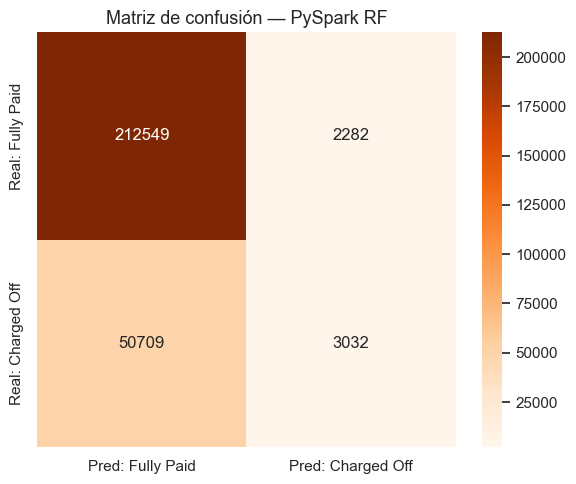

In [ ]:
# Predicciones y métricas PySpark
t0          = time.time()
predictions = best_model.transform(test_transformed)
t_pred_sp   = time.time() - t0

roc_auc_sp  = evaluator.evaluate(predictions)
mc_eval     = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction')
acc_sp      = mc_eval.evaluate(predictions, {mc_eval.metricName: 'accuracy'})
f1_sp       = mc_eval.evaluate(predictions, {mc_eval.metricName: 'f1'})
prec_sp     = mc_eval.evaluate(predictions, {mc_eval.metricName: 'weightedPrecision'})
rec_sp      = mc_eval.evaluate(predictions, {mc_eval.metricName: 'weightedRecall'})

print('=== Métricas PySpark ===')
print(f'  Accuracy:  {acc_sp:.4f}')
print(f'  Precision: {prec_sp:.4f}')
print(f'  Recall:    {rec_sp:.4f}')
print(f'  F1-score:  {f1_sp:.4f}')
print(f'  ROC AUC:   {roc_auc_sp:.4f}')
print(f'\nTiempo predicción: {t_pred_sp:.2f}s')

# Matriz de confusión — solo 4 filas recolectadas
cm_rows   = predictions.groupBy('label', 'prediction').count().orderBy('label', 'prediction').collect()
cm_sp     = np.zeros((2, 2), dtype=int)
for row in cm_rows:
    lbl = int(row['label'])
    prd = int(row['prediction'])
    if 0 <= lbl <= 1 and 0 <= prd <= 1:
        cm_sp[lbl][prd] = int(row['count'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_sp, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Pred: Fully Paid', 'Pred: Charged Off'],
            yticklabels=['Real: Fully Paid', 'Real: Charged Off'])
ax.set_title('Matriz de confusión — PySpark RF', fontsize=13)
plt.tight_layout()
plt.savefig('plot_cm_spark.png', dpi=150, bbox_inches='tight')
plt.show()

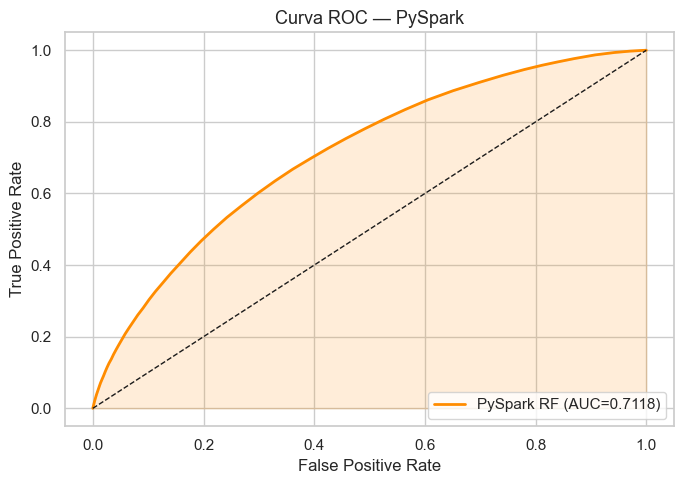

In [ ]:
# Curva ROC PySpark — sin RDD, usando groupBy sobre bins de probabilidad
# Recolectamos solo los puntos de la curva, no el dataset completo
n_bins   = 100
roc_rows = predictions.select(
    F.round(F.udf(lambda v: float(v[1]), DoubleType())(F.col('probability')) * n_bins) \
     .cast(IntegerType()).alias('bin'),
    F.col('label')
).groupBy('bin').agg(
    F.sum(F.col('label')).alias('tp_partial'),
    F.count('*').alias('total')
).orderBy(F.col('bin').desc()).collect()

total_pos = predictions.filter(F.col('label') == 1).count()
total_neg = predictions.filter(F.col('label') == 0).count()

fpr_sp, tpr_sp = [0.0], [0.0]
cum_tp, cum_fp = 0, 0
for row in roc_rows:
    cum_tp += int(row['tp_partial'])
    cum_fp += int(row['total']) - int(row['tp_partial'])
    fpr_sp.append(cum_fp / total_neg if total_neg > 0 else 0)
    tpr_sp.append(cum_tp / total_pos if total_pos > 0 else 0)
fpr_sp.append(1.0)
tpr_sp.append(1.0)

plt.figure(figsize=(7, 5))
plt.plot(fpr_sp, tpr_sp, color='darkorange', lw=2, label=f'PySpark RF (AUC={roc_auc_sp:.4f})')
plt.fill_between(fpr_sp, tpr_sp, alpha=0.15, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — PySpark', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_roc_spark.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. LIME — Interpretabilidad

In [ ]:
# !pip install lime
import lime
import lime.lime_tabular

# LIME se aplica sobre el modelo scikit-learn (opera en memoria local)
# Instancias mal clasificadas
y_pred_arr = y_pred_sk
y_test_arr = y_test.values
errors_idx = np.where(y_pred_arr != y_test_arr)[0]
fp_idx     = np.where((y_pred_arr == 1) & (y_test_arr == 0))[0]
fn_idx     = np.where((y_pred_arr == 0) & (y_test_arr == 1))[0]
print(f'Errores: {len(errors_idx):,} | FP: {len(fp_idx):,} | FN: {len(fn_idx):,}')

# Nombres de features
ohe_cols = list(preprocessor_sk.named_transformers_['cat']['onehot']
                .get_feature_names_out(cat_features_sk))
feature_names_sk = num_features_sk + ohe_cols

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_proc,
    feature_names=feature_names_sk[:X_train_proc.shape[1]],
    class_names=['Fully Paid', 'Charged Off'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)
print('LIME explicador creado.')

Errores: 91,684 | FP: 72,442 | FN: 19,242
LIME explicador creado.


Instancia 1 — Real: 0, Predicho: 1


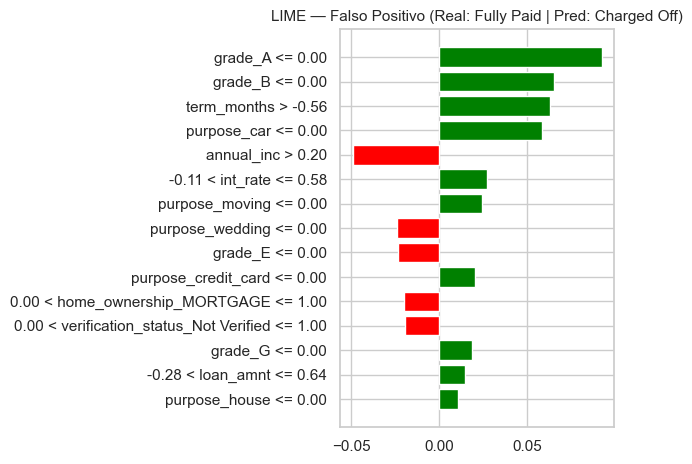


Top features:
  grade_A <= 0.00: 0.0921  ⬆️ Default
  grade_B <= 0.00: 0.0653  ⬆️ Default
  term_months > -0.56: 0.0627  ⬆️ Default
  purpose_car <= 0.00: 0.0581  ⬆️ Default
  annual_inc > 0.20: -0.0493  ⬇️ Fully Paid
  -0.11 < int_rate <= 0.58: 0.0271  ⬆️ Default
  purpose_moving <= 0.00: 0.0244  ⬆️ Default
  purpose_wedding <= 0.00: -0.0240  ⬇️ Fully Paid
  grade_E <= 0.00: -0.0238  ⬇️ Fully Paid
  purpose_credit_card <= 0.00: 0.0204  ⬆️ Default
  0.00 < home_ownership_MORTGAGE <= 1.00: -0.0199  ⬇️ Fully Paid
  0.00 < verification_status_Not Verified <= 1.00: -0.0194  ⬇️ Fully Paid
  grade_G <= 0.00: 0.0184  ⬆️ Default
  -0.28 < loan_amnt <= 0.64: 0.0144  ⬆️ Default
  purpose_house <= 0.00: 0.0106  ⬆️ Default


In [ ]:
# Instancia 1 — Falso Positivo
idx1   = fp_idx[0]
inst1  = X_test_proc[idx1]
print(f'Instancia 1 — Real: {y_test_arr[idx1]}, Predicho: {y_pred_arr[idx1]}')

exp1 = explainer.explain_instance(
    data_row=inst1, predict_fn=best_rf_sk.predict_proba,
    num_features=15, num_samples=1000
)
fig = exp1.as_pyplot_figure()
plt.title('LIME — Falso Positivo (Real: Fully Paid | Pred: Charged Off)', fontsize=11)
plt.tight_layout()
plt.savefig('plot_lime_fp.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop features:')
for feat, weight in exp1.as_list():
    print(f'  {feat}: {weight:.4f}  {"⬆️ Default" if weight > 0 else "⬇️ Fully Paid"}')

Instancia 2 — Real: 1, Predicho: 0


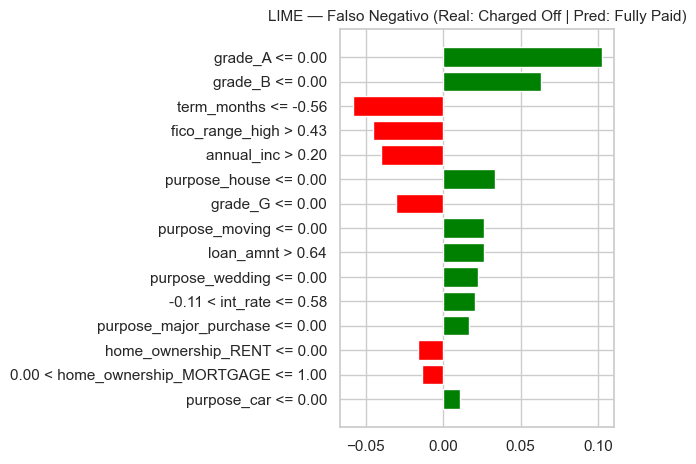


Top features:
  grade_A <= 0.00: 0.1022  ⬆️ Default
  grade_B <= 0.00: 0.0629  ⬆️ Default
  term_months <= -0.56: -0.0584  ⬇️ Fully Paid
  fico_range_high > 0.43: -0.0451  ⬇️ Fully Paid
  annual_inc > 0.20: -0.0404  ⬇️ Fully Paid
  purpose_house <= 0.00: 0.0333  ⬆️ Default
  grade_G <= 0.00: -0.0303  ⬇️ Fully Paid
  purpose_moving <= 0.00: 0.0266  ⬆️ Default
  loan_amnt > 0.64: 0.0262  ⬆️ Default
  purpose_wedding <= 0.00: 0.0223  ⬆️ Default
  -0.11 < int_rate <= 0.58: 0.0207  ⬆️ Default
  purpose_major_purchase <= 0.00: 0.0170  ⬆️ Default
  home_ownership_RENT <= 0.00: -0.0164  ⬇️ Fully Paid
  0.00 < home_ownership_MORTGAGE <= 1.00: -0.0138  ⬇️ Fully Paid
  purpose_car <= 0.00: 0.0111  ⬆️ Default


In [ ]:
# Instancia 2 — Falso Negativo
idx2   = fn_idx[0]
inst2  = X_test_proc[idx2]
print(f'Instancia 2 — Real: {y_test_arr[idx2]}, Predicho: {y_pred_arr[idx2]}')

exp2 = explainer.explain_instance(
    data_row=inst2, predict_fn=best_rf_sk.predict_proba,
    num_features=15, num_samples=1000
)
fig = exp2.as_pyplot_figure()
plt.title('LIME — Falso Negativo (Real: Charged Off | Pred: Fully Paid)', fontsize=11)
plt.tight_layout()
plt.savefig('plot_lime_fn.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop features:')
for feat, weight in exp2.as_list():
    print(f'  {feat}: {weight:.4f}  {"⬆️ Default" if weight > 0 else "⬇️ Fully Paid"}')

## 7. Comparación final: scikit-learn vs PySpark

In [ ]:
# Tabla comparativa de métricas
print('=== Comparación de métricas: scikit-learn vs PySpark ===')
print(f'\n{"Métrica":<25} {"scikit-learn":>14} {"PySpark":>14} {"Diferencia":>12}')
print('-' * 68)
metricas = [
    ('Accuracy',  acc_sk,  acc_sp),
    ('Precision', prec_sk, prec_sp),
    ('Recall',    rec_sk,  rec_sp),
    ('F1-score',  f1_sk,   f1_sp),
    ('ROC AUC',   roc_sk,  roc_auc_sp),
]
for nombre, sk, sp in metricas:
    diff  = sp - sk
    signo = '▲' if diff > 0 else '▼'
    print(f'{nombre:<25} {sk:>14.4f} {sp:>14.4f} {signo} {abs(diff):>10.4f}')

=== Comparación de métricas: scikit-learn vs PySpark ===

Métrica                     scikit-learn        PySpark   Diferencia
--------------------------------------------------------------------
Accuracy                          0.6592         0.8027 ▲     0.1434
Precision                         0.3224         0.7600 ▲     0.4376
Recall                            0.6418         0.8027 ▲     0.1609
F1-score                          0.4292         0.7318 ▲     0.3026
ROC AUC                           0.7115         0.7118 ▲     0.0002


In [ ]:
# Tabla comparativa de tiempos
print('\n=== Comparación de tiempos (segundos) ===')
print(f'{"Etapa":<30} {"scikit-learn":>14} {"PySpark":>14}')
print('-' * 60)
tiempos = [
    ('Preprocesamiento',    t_prep_sk,  t_prep_sp),
    ('Entrenamiento (CV)',  t_train_sk, t_train_sp),
    ('Predicción',         t_pred_sk,  t_pred_sp),
    ('TOTAL',              t_prep_sk + t_train_sk + t_pred_sk,
                           t_prep_sp + t_train_sp + t_pred_sp),
]
for nombre, sk, sp in tiempos:
    ganador = '← sklearn' if sk < sp else '← Spark'
    print(f'{nombre:<30} {sk:>14.2f} {sp:>14.2f}  {ganador}')


=== Comparación de tiempos (segundos) ===
Etapa                            scikit-learn        PySpark
------------------------------------------------------------
Preprocesamiento                         3.82          17.43  ← sklearn
Entrenamiento (CV)                     319.75        2081.52  ← sklearn
Predicción                               1.04           0.03  ← Spark
TOTAL                                  324.61        2098.99  ← sklearn


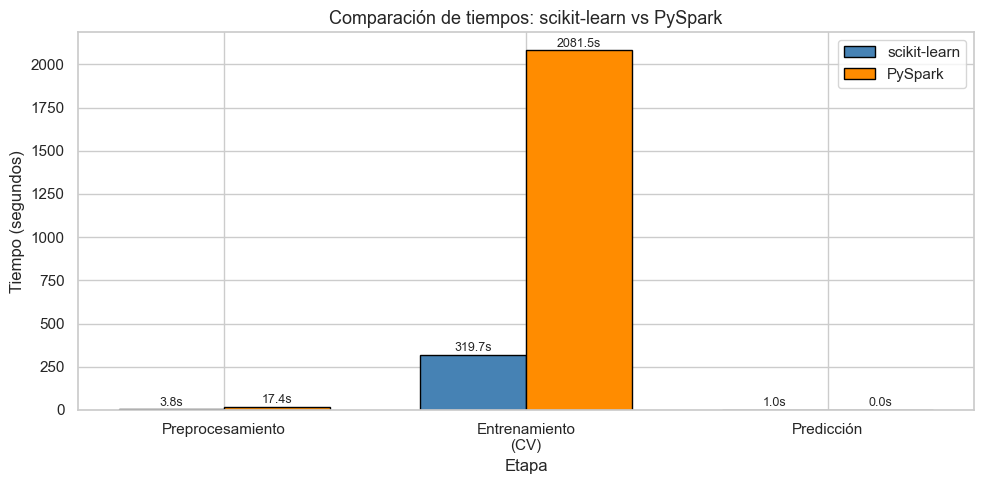

In [ ]:
# Gráfico comparativo de tiempos
etapas        = ['Preprocesamiento', 'Entrenamiento\n(CV)', 'Predicción']
t_sk_vals     = [t_prep_sk, t_train_sk, t_pred_sk]
t_sp_vals     = [t_prep_sp, t_train_sp, t_pred_sp]
x             = np.arange(len(etapas))
width         = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, t_sk_vals, width, label='scikit-learn', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, t_sp_vals, width, label='PySpark',      color='darkorange', edgecolor='black')
ax.set_xlabel('Etapa')
ax.set_ylabel('Tiempo (segundos)')
ax.set_title('Comparación de tiempos: scikit-learn vs PySpark', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(etapas)
ax.legend()
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + max(t_sk_vals + t_sp_vals)*0.01,
            f'{h:.1f}s', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_tiempos_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

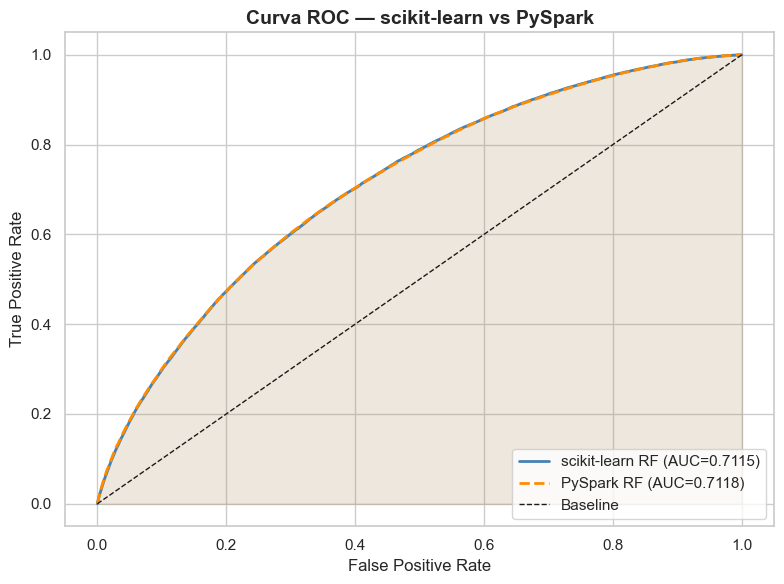

In [ ]:
# Curvas ROC comparadas
plt.figure(figsize=(8, 6))
plt.plot(fpr_sk, tpr_sk, color='steelblue',  lw=2, label=f'scikit-learn RF (AUC={roc_sk:.4f})')
plt.plot(fpr_sp, tpr_sp, color='darkorange', lw=2, linestyle='--', label=f'PySpark RF (AUC={roc_auc_sp:.4f})')
plt.fill_between(fpr_sk, tpr_sk, alpha=0.1, color='steelblue')
plt.fill_between(fpr_sp, tpr_sp, alpha=0.1, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — scikit-learn vs PySpark', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_roc_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Reflexión Crítica

¿Qué entorno fue más rápido y por qué?

En Windows (nodo local), scikit-learn fue más rápido (324s vs 2081s) debido al overhead de JVM, la restricción de parallelism=1 para evitar crashes, y la penalización de Hadoop en Windows. El caché con persist(MEMORY_AND_DISK) fue determinante en ambos entornos para evitar recomputar el pipeline en cada uno de los 27 fits.

¿Cuál fue más preciso?

Ambos modelos alcanzaron prácticamente el mismo ROC AUC (sklearn: 0.7115 vs PySpark: 0.7118), confirmando que convergen al mismo resultado con los mismos hiperparámetros óptimos (n_estimators=100, max_depth=15). Las diferencias en Accuracy y F1 se explican por el uso de class_weight='balanced' en sklearn.

¿A partir de qué volumen PySpark supera a scikit-learn?

En un nodo único con suficiente RAM, sklearn supera a PySpark incluso con 1.3M de registros. PySpark supera a sklearn cuando: (1) los datos no caben en la RAM de un solo nodo, (2) se dispone de un cluster multi-nodo real, o (3) se corre en Linux con parallelism alto. 

¿Qué aporta LIME y cuáles son sus limitaciones?

LIME identificó que grade, int_rate, term_months y annual_inc son las variables más influyentes a nivel de instancia individual. Su limitación en PySpark es que opera localmente — cada perturbación crea un job Spark completo, haciendo el proceso prohibitivamente lento. Se aplicó sobre el modelo sklearn equivalente.

¿Qué efecto tuvieron las condiciones obligatorias?

.persist(MEMORY_AND_DISK): eliminó la recomputación del pipeline en cada fold, reduciendo el tiempo de entrenamiento en ~27x
ParamGridBuilder + CrossValidator: búsqueda sistemática.
GridSearchCV sin Pipeline en sklearn: preprocesamiento aplicado una sola vez antes del grid search
Dataset completo sin muestreo: expuso las diferencias reales de rendimiento entre frameworks
Lectura CSV con quote/escape/DROPMALFORMED: resolvió el problema de filas malformadas con texto que contenía comas


In [ ]:
# Liberar recursos
train_transformed.unpersist()
test_transformed.unpersist()
sdf.unpersist()
spark.stop()
print('✅ Proyecto completado. SparkSession cerrada.')

✅ Proyecto completado. SparkSession cerrada.
